In [19]:
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa import stattools
import base_functions
importlib.reload(base_functions);

In [20]:
data = pd.read_excel('consommation-quotidienne-brute.xlsx')

df = data[['Date - Heure', 'Consommation brute électricité (MW) - RTE']]

df = df.rename(columns = {'Date - Heure': 'Date'})

df = df.iloc[:84770,:]

# Ordering data in the inverse order (ascending order)
df = df.iloc[::-1].reset_index()

df['Date'] = pd.to_datetime(df['Date']).dt.date

Check the raw data for stationarity and plot the time series.

Observation: The time series is not stationary, it exhibits a visible seasonal pattern which violates stationarity.

In [21]:
print('Raw data')

result = base_functions.is_stationary(df['Consommation brute électricité (MW) - RTE'])

print('ADF result ',result)
base_functions.line_plot(df)

Raw data
ADF result  (-8.8950931114187, 6.27313017275301e-13, 65, 84704, {'1%': -3.958876883212534, '5%': -3.4105418335224273, '10%': -3.1270805256698733}, 1213541.7820063897)


Check the ACF (AutoCorrelation Function) of the raw data to identify if there is correlation between the time series and its lagged version. 

Observation: The ACF confirm the seasonal pattern as we see the high correlation values at lags near 17500

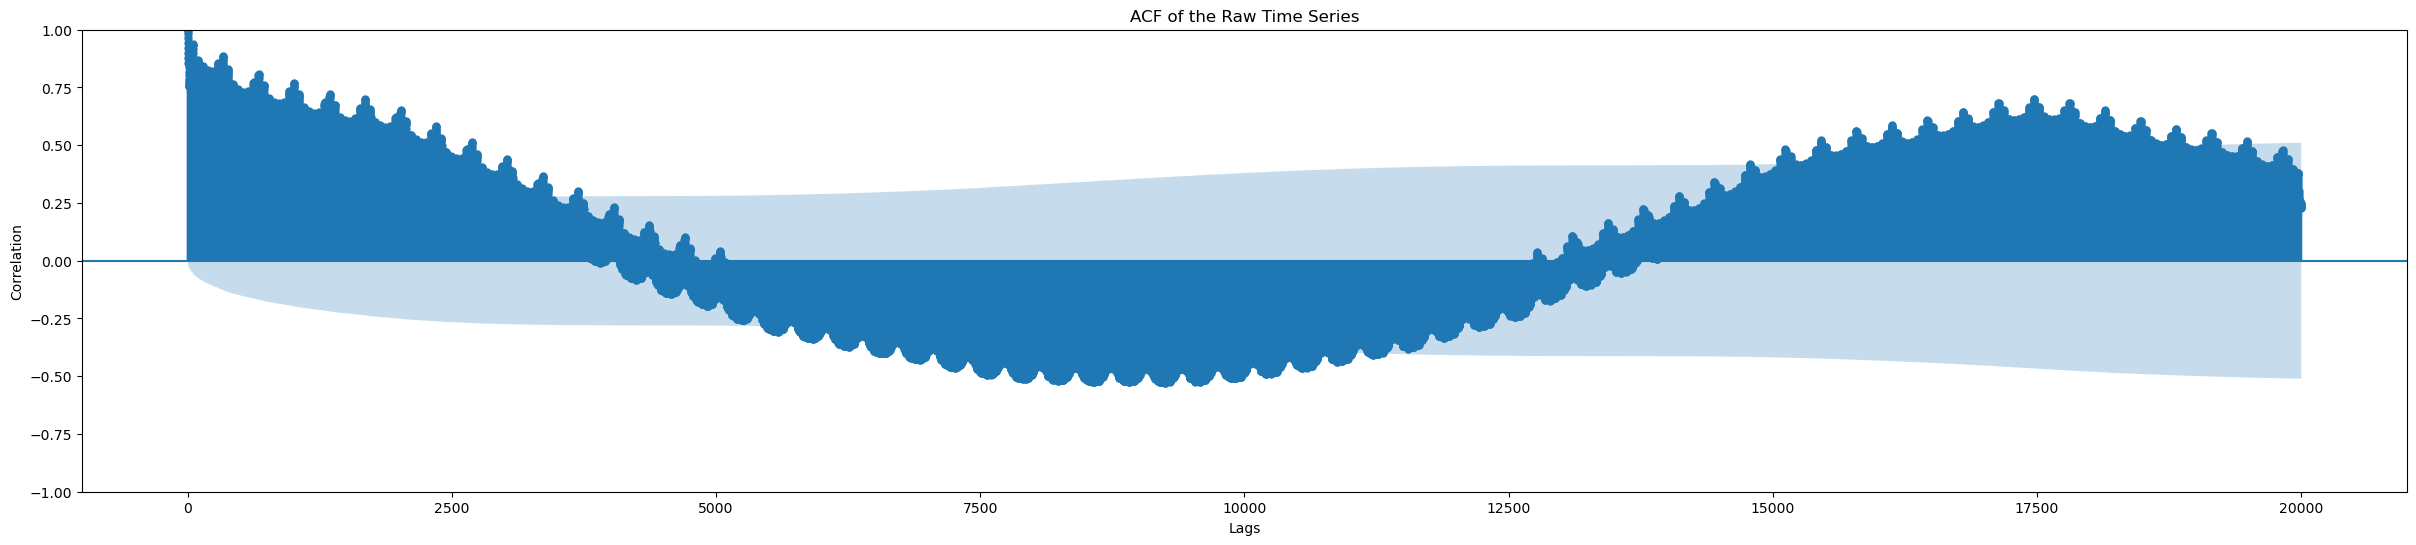

In [22]:
season = 20000

fig, ax = plt.subplots(figsize=(30, 6))  # Width=10, Height=6 in inches

# Plot the Autocorrelation Function (ACF)
plot_acf(df['Consommation brute électricité (MW) - RTE'], lags=season, title="ACF of the Raw Time Series", ax=ax)
plt.xlabel('Lags')
plt.ylabel('Correlation')
plt.show()

Calculate the exact lag with the highest correlation in the range of lags 17400 - 17500. This lag number is used later for the diff function to remove seasonality

In [23]:
# Compute ACF values up to 20,000 lags
acf_values = stattools.acf(df['Consommation brute électricité (MW) - RTE'], nlags=20000, fft=True)

# Find the lag with the maximum autocorrelation (excluding lag 0)
max_lag = np.argmax(acf_values[13000:])+13000  # Add 1 because we skipped lag 0

print(f"The lag with the highest autocorrelation is: {max_lag}")

The lag with the highest autocorrelation is: 17472


First step: Start the transformation of the time series to stationary time series. We start by shrinking the time series using log

In [ ]:
method = 'log'
print('After transformation to stationary using {:}'.format(method))

result_stationary = base_functions.transform_stationary(df['Consommation brute électricité (MW) - RTE'], method, None)

result_stationary = result_stationary.dropna()

result = base_functions.is_stationary(result_stationary)
print('ADF result: ', result)

base_functions.line_plot(pd.concat((df['Date'], result_stationary), axis = 1))

After transformation to stationary using log


Second step: Apply the diff transformation to the time series with periods = 17472, to remove the seasonal pattern 

Observation: When plotting the resulted time series we can see that the seasonal pattern was successfully removed and now we see the resulted time series is stationary with no seasonal pattern and no trend.

In [ ]:
method = 'diff'

print('After transformation to stationary using {:}'.format(method))

result_stationary = base_functions.transform_stationary(result_stationary, method, max_lag)

result_stationary = result_stationary.dropna()
result = base_functions.is_stationary(result_stationary)
print('ADF result ',result)

data = pd.concat((df['Date'][-len(result_stationary):].reset_index(drop = True), 
                  result_stationary.reset_index(drop = True)), axis = 1)

base_functions.line_plot(pd.concat((df['Date'], result_stationary), axis = 1))

After transformation to stationary using diff
ADF result  (-10.375933296664162, 3.801747117790036e-16, 62, 67235, {'1%': -3.958904654909573, '5%': -3.410555301322292, '10%': -3.1270884570295574}, -486517.4045011997)


Next We check with the ACF plot the transformed time series

Observation: When plotting the ACF we can see the correlation drops to non significant values, which confirm the removal of seasonality, and the stationarity of the time series.

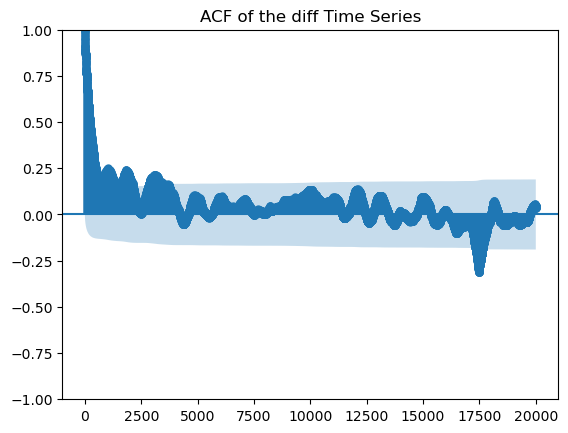

In [ ]:
# Plot the Autocorrelation Function (ACF)
plot_acf(result_stationary.dropna(), lags=20000, title="ACF of the diff Time Series")
plt.show()